# AAI590 Capstone — Group 4
## Module 3 | Notebook 1: CirCor DigiScope Data Download & Verification

**Project**: ML-Based Murmur Detection for RHD Screening Using Phonocardiogram Data  
**Dataset**: CirCor DigiScope Phonocardiogram Dataset v1.0.3 (PhysioNet)  
**Authors**: Shiva Bathula · Kaushik M · Pavan Kumar Bellary  

---

### Notebook goals
1. Install required libraries
2. Download the dataset from PhysioNet (or Kaggle mirror for faster re-downloads)
3. Verify the download — file counts, directory structure
4. Load one sample `.wav` recording + its annotation to confirm everything works
5. Inspect the master `training_data.csv` label file

> **Note**: PhysioNet requires a free account. Before running Cell 3 (wget download),  
> go to https://physionet.org/register/ and create an account, then accept the  
> CirCor DUA at https://physionet.org/content/circor-heart-sound/1.0.3/  
> Your credentials will be entered in Cell 3.

---
## 1. Install & Import Libraries

In [1]:
# ── Install ───────────────────────────────────────────────────────────────────
!pip install librosa soundfile wfdb --quiet

# ── Standard imports ─────────────────────────────────────────────────────────
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import IPython.display as ipd
from pathlib import Path

print('Libraries loaded successfully.')
print(f'librosa version: {librosa.__version__}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 101.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
Libraries loaded successfully.
librosa version: 0.11.0


---
## 2. Configure Paths

In [2]:
# ── Root data directory (change if needed) ────────────────────────────────────
DATA_ROOT = Path('/content/circor-heart-sound')
AUDIO_DIR = DATA_ROOT / 'training_data'
LABEL_CSV = DATA_ROOT / 'training_data.csv'

# Create root folder
DATA_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Data root: {DATA_ROOT}')

Data root: /content/circor-heart-sound


---
## 3. Download Dataset

**Option A** — PhysioNet `wget` (official, ~2–3 GB, slower in Colab but always available)  
**Option B** — Kaggle mirror (faster for repeated Colab sessions, requires Kaggle API key)

Run **only one** of the two cells below.

In [3]:
# ── OPTION A: PhysioNet wget download ─────────────────────────────────────────
# Enter your PhysioNet username and password when prompted.
# This downloads the full v1.0.3 dataset (~2.4 GB, 5272 wav files).

import getpass

PHYSIONET_USER = input('PhysioNet username: ')
PHYSIONET_PASS = getpass.getpass('PhysioNet password: ')

# Download only training_data folder — faster than full dataset
!wget -r -N -c -np \
    --user="{PHYSIONET_USER}" \
    --password="{PHYSIONET_PASS}" \
    -P /content/circor-heart-sound \
    https://physionet.org/files/circor-heart-sound/1.0.3/training_data/

# Also grab the label CSV separately
!wget -N \
    --user="{PHYSIONET_USER}" \
    --password="{PHYSIONET_PASS}" \
    -P /content/circor-heart-sound \
    https://physionet.org/files/circor-heart-sound/1.0.3/training_data.csv

# Flatten the nested directory
import shutil
from pathlib import Path

nested = Path('/content/circor-heart-sound/physionet.org/files/circor-heart-sound/1.0.3')
DATA_ROOT = Path('/content/circor-heart-sound')

if nested.exists():
    for item in nested.iterdir():
        dest = DATA_ROOT / item.name
        if not dest.exists():
            shutil.move(str(item), str(DATA_ROOT))
    shutil.rmtree('/content/circor-heart-sound/physionet.org')
    print('✅ Directory flattened.')

# Verify
wav_files = list(Path('/content/circor-heart-sound/training_data').glob('*.wav'))
print(f'WAV files: {len(wav_files)}')
print(f'Label CSV: {Path("/content/circor-heart-sound/training_data.csv").exists()}')

Streaming output truncated to the last 5000 lines.

2026-07-08 07:13:44 (411 MB/s) - ‘/content/circor-heart-sound/physionet.org/files/circor-heart-sound/1.0.3/training_data/85276.txt’ saved [569/569]

--2026-07-08 07:13:44--  https://physionet.org/files/circor-heart-sound/1.0.3/training_data/85276_MV.hea
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 59 [text/plain]
Saving to: ‘/content/circor-heart-sound/physionet.org/files/circor-heart-sound/1.0.3/training_data/85276_MV.hea’

physionet.org/files 100%[===================>]      59  --.-KB/s    in 0s      

2026-07-08 07:13:44 (44.3 MB/s) - ‘/content/circor-heart-sound/physionet.org/files/circor-heart-sound/1.0.3/training_data/85276_MV.hea’ saved [59/59]

--2026-07-08 07:13:44--  https://physionet.org/files/circor-heart-sound/1.0.3/training_data/85276_MV.tsv
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1193 (1.2K) [text

---
## 4. Verify Download — File Counts & Directory Structure

In [4]:
# ── Count files by type ───────────────────────────────────────────────────────
wav_files  = list(AUDIO_DIR.glob('**/*.wav'))
tsv_files  = list(AUDIO_DIR.glob('**/*.tsv'))   # segmentation annotations
txt_files  = list(AUDIO_DIR.glob('**/*.txt'))   # per-subject summaries

print('── Download verification ──────────────────────────────')
print(f'  WAV recordings   : {len(wav_files):>5}  (expected ~5,272)')
print(f'  TSV seg files    : {len(tsv_files):>5}')
print(f'  TXT subject files: {len(txt_files):>5}')
print(f'  Label CSV exists : {LABEL_CSV.exists()}')
print()

# Show first 5 wav files
print('Sample WAV file paths:')
for f in sorted(wav_files)[:5]:
    print(f'  {f.name}')

── Download verification ──────────────────────────────
  WAV recordings   :  3163  (expected ~5,272)
  TSV seg files    :  3163
  TXT subject files:   942
  Label CSV exists : True

Sample WAV file paths:
  13918_AV.wav
  13918_MV.wav
  13918_PV.wav
  13918_TV.wav
  14241_AV.wav


---
## 5. Load & Inspect the Label CSV

In [5]:
# ── Load master label file ────────────────────────────────────────────────────
df = pd.read_csv(LABEL_CSV)

print(f'Shape: {df.shape}  ({df.shape[0]} patients, {df.shape[1]} columns)')
print()
print('Columns:')
print(df.columns.tolist())
print()
df.head()

Shape: (942, 23)  (942 patients, 23 columns)

Columns:
['Patient ID', 'Recording locations:', 'Age', 'Sex', 'Height', 'Weight', 'Pregnancy status', 'Murmur', 'Murmur locations', 'Most audible location', 'Systolic murmur timing', 'Systolic murmur shape', 'Systolic murmur grading', 'Systolic murmur pitch', 'Systolic murmur quality', 'Diastolic murmur timing', 'Diastolic murmur shape', 'Diastolic murmur grading', 'Diastolic murmur pitch', 'Diastolic murmur quality', 'Outcome', 'Campaign', 'Additional ID']



,Patient ID,Recording locations:,Age,Sex,Height,Weight,Pregnancy status,Murmur,Murmur locations,Most audible location,...,Systolic murmur pitch,Systolic murmur quality,Diastolic murmur timing,Diastolic murmur shape,Diastolic murmur grading,Diastolic murmur pitch,Diastolic murmur quality,Outcome,Campaign,Additional ID
0,2530,AV+PV+TV+MV,Child,Female,98.0,15.9,False,Absent,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abnormal,CC2015,NaN
1,9979,AV+PV+TV+MV,Child,Female,103.0,13.1,False,Present,AV+MV+PV+TV,TV,...,High,Harsh,NaN,NaN,NaN,NaN,NaN,Abnormal,CC2015,NaN
2,9983,AV+PV+TV+MV,Child,Male,115.0,19.1,False,Unknown,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abnormal,CC2015,NaN
3,13918,AV+PV+TV+MV,Child,Male,98.0,15.9,False,Present,TV,TV,...,Low,Blowing,NaN,NaN,NaN,NaN,NaN,Abnormal,CC2015,NaN
4,14241,AV+PV+TV+MV,Child,Male,87.0,11.2,False,Present,AV+MV+PV+TV,PV,...,Low,Harsh,NaN,NaN,NaN,NaN,NaN,Abnormal,CC2015,NaN


── Murmur label distribution ─────────────────────────
Murmur
Absent     695
Present    179
Unknown     68
Name: count, dtype: int64

── Clinical outcome distribution ─────────────────────
Outcome
Normal      486
Abnormal    456
Name: count, dtype: int64



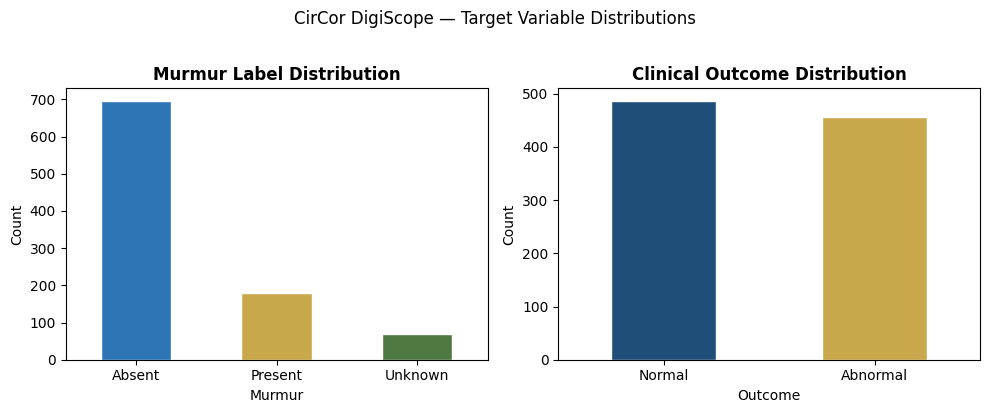

Plot saved to /content/label_distributions.png


In [6]:
# ── Key label distributions ───────────────────────────────────────────────────
print('── Murmur label distribution ─────────────────────────')
print(df['Murmur'].value_counts())
print()
print('── Clinical outcome distribution ─────────────────────')
print(df['Outcome'].value_counts())
print()

# Quick class-balance check — this is the target variable we'll classify
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df['Murmur'].value_counts().plot(kind='bar', ax=axes[0], color=['#2E75B6','#C9A84C','#4F7942'],
                                  edgecolor='white')
axes[0].set_title('Murmur Label Distribution', fontweight='bold')
axes[0].set_xlabel('Murmur')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['Outcome'].value_counts().plot(kind='bar', ax=axes[1], color=['#1F4E79','#C9A84C'],
                                   edgecolor='white')
axes[1].set_title('Clinical Outcome Distribution', fontweight='bold')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('CirCor DigiScope — Target Variable Distributions', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('/content/label_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to /content/label_distributions.png')

---
## 6. Load One Sample Recording & Visualise

In [7]:
# ── Pick the first WAV file and load it with librosa ─────────────────────────
sample_wav = sorted(wav_files)[0]
patient_id = sample_wav.stem.split('_')[0]
auscultation_site = sample_wav.stem.split('_')[1] if '_' in sample_wav.stem else 'Unknown'

y, sr = librosa.load(str(sample_wav), sr=None)   # sr=None preserves original sample rate

print(f'File          : {sample_wav.name}')
print(f'Patient ID    : {patient_id}')
print(f'Auscultation  : {auscultation_site}')
print(f'Sample rate   : {sr} Hz')
print(f'Duration      : {len(y)/sr:.2f} seconds')
print(f'Samples       : {len(y):,}')
print()

# Patient label
if patient_id.isdigit():
    row = df[df['Patient ID'] == int(patient_id)]
    if not row.empty:
        print(f'Murmur label  : {row["Murmur"].values[0]}')
        print(f'Outcome label : {row["Outcome"].values[0]}')

File          : 13918_AV.wav
Patient ID    : 13918
Auscultation  : AV
Sample rate   : 4000 Hz
Duration      : 10.29 seconds
Samples       : 41,152

Murmur label  : Present
Outcome label : Abnormal


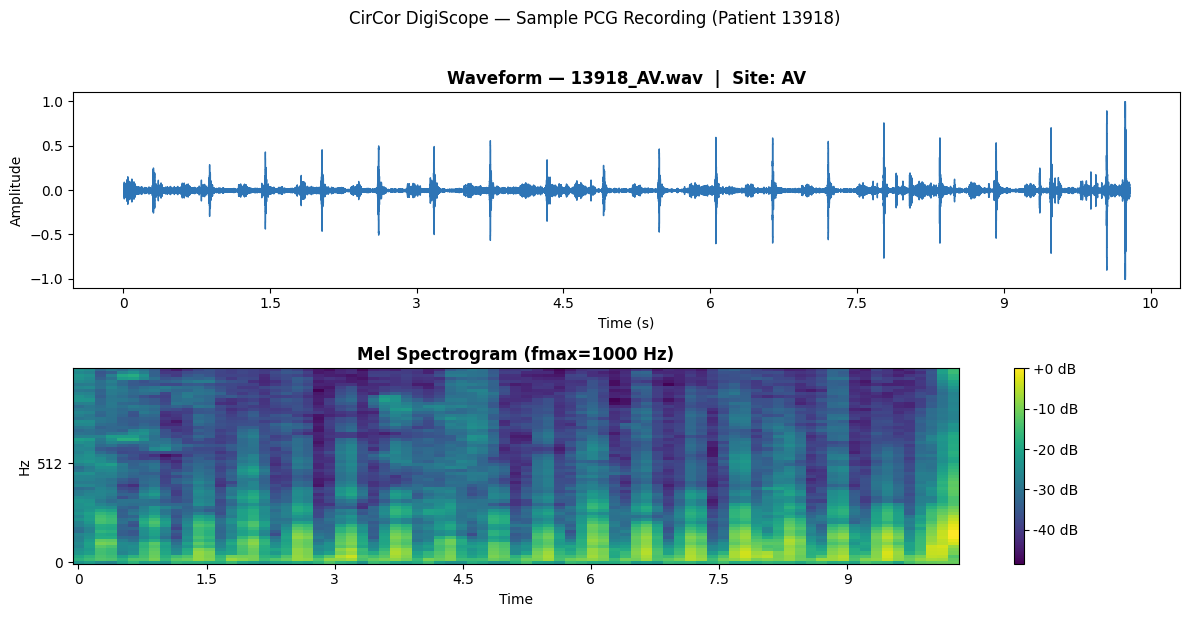

Plot saved.


In [8]:
# ── Plot waveform + spectrogram side by side ──────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Waveform
librosa.display.waveshow(y, sr=sr, ax=axes[0], color='#2E75B6')
axes[0].set_title(f'Waveform — {sample_wav.name}  |  Site: {auscultation_site}', fontweight='bold')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

# Mel spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, fmax=1000)
S_db = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel',
                                fmax=1000, ax=axes[1], cmap='viridis')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
axes[1].set_title('Mel Spectrogram (fmax=1000 Hz)', fontweight='bold')

plt.suptitle(f'CirCor DigiScope — Sample PCG Recording (Patient {patient_id})',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('/content/sample_pcg_waveform_spectrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [9]:
# ── Play the audio directly in Colab ─────────────────────────────────────────
print(f'Playing: {sample_wav.name}')
ipd.Audio(y, rate=sr)

Playing: 13918_AV.wav


---
## 7. Inspect a Segmentation Annotation File (.tsv)

In [10]:
# ── Find the .tsv segmentation file matching the sample WAV ──────────────────
tsv_stem = sample_wav.stem          # e.g. '50001_AV'
tsv_path = AUDIO_DIR / f'{tsv_stem}.tsv'

if tsv_path.exists():
    seg_df = pd.read_csv(tsv_path, sep='\t', header=None,
                         names=['start_sample', 'end_sample', 'label'])
    print(f'Segmentation file: {tsv_path.name}')
    print(f'Segments: {len(seg_df)}')
    print()
    print('Label key: 1=S1  2=systole  3=S2  4=diastole')
    print()
    print(seg_df.head(12).to_string(index=False))
else:
    print(f'No .tsv found for {tsv_stem} — trying first available .tsv')
    if tsv_files:
        seg_df = pd.read_csv(tsv_files[0], sep='\t', header=None,
                             names=['start_sample', 'end_sample', 'label'])
        print(seg_df.head(12).to_string(index=False))

Segmentation file: 13918_AV.tsv
Segments: 61

Label key: 1=S1  2=systole  3=S2  4=diastole

 start_sample  end_sample  label
     0.000000    1.146750      0
     1.146750    1.300191      1
     1.300191    1.400191      2
     1.400191    1.540191      3
     1.540191    1.779916      4
     1.779916    1.900191      1
     1.900191    1.980191      2
     1.980191    2.100191      3
     2.100191    2.320036      4
     2.320036    2.460191      1
     2.460191    2.560191      2
     2.560191    2.700191      3


---
## 8. Quick Dataset Summary

In [11]:
# ── Demographic snapshot ──────────────────────────────────────────────────────
print('── Dataset Summary ───────────────────────────────────────────────────')
print(f'  Total patients           : {df.shape[0]}')
print(f'  Total WAV recordings     : {len(wav_files)}')
print(f'  Avg recordings/patient   : {len(wav_files)/df.shape[0]:.1f}')
print()

if 'Age' in df.columns:
    print(f'  Age range                : {df["Age"].min()} – {df["Age"].max()}')
if 'Sex' in df.columns:
    print(f'  Sex distribution:')
    print(df['Sex'].value_counts().to_string())

print()
print('── Auscultation sites in filenames ───────────────────────────────────')
sites = [f.stem.split('_')[1] if '_' in f.stem else 'other' for f in wav_files]
from collections import Counter
for site, count in Counter(sites).most_common():
    print(f'  {site:<8}: {count:>5} recordings')

print()
print('── Data types ────────────────────────────────────────────────────────')
print(df.dtypes)
print()
print('── Missing values ────────────────────────────────────────────────────')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values.')

── Dataset Summary ───────────────────────────────────────────────────
  Total patients           : 942
  Total WAV recordings     : 3163
  Avg recordings/patient   : 3.4

  Age range                : Adolescent – Neonate
  Sex distribution:
Sex
Female    486
Male      456

── Auscultation sites in filenames ───────────────────────────────────
  MV      :   861 recordings
  AV      :   800 recordings
  PV      :   766 recordings
  TV      :   732 recordings
  Phc     :     4 recordings

── Data types ────────────────────────────────────────────────────────
Patient ID                    int64
Recording locations:            str
Age                             str
Sex                             str
Height                      float64
Weight                      float64
Pregnancy status               bool
Murmur                          str
Murmur locations                str
Most audible location           str
Systolic murmur timing          str
Systolic murmur shape           str
Systo

---
## 9. Save Verified File Index for Use in Subsequent Notebooks

In [12]:
# ── Build a file index DataFrame linking WAV paths to patient labels ──────────
records = []
for wav in sorted(wav_files):
    parts = wav.stem.split('_')
    pid   = int(parts[0]) if parts[0].isdigit() else None
    site  = parts[1] if len(parts) > 1 else 'unknown'
    records.append({'patient_id': pid, 'site': site, 'wav_path': str(wav)})

file_index = pd.DataFrame(records)

# Merge with label CSV
if 'Patient ID' in df.columns:
    file_index = file_index.merge(df[['Patient ID','Murmur','Outcome']],
                                   left_on='patient_id', right_on='Patient ID',
                                   how='left').drop(columns=['Patient ID'])

INDEX_PATH = '/content/circor_file_index.csv'
file_index.to_csv(INDEX_PATH, index=False)

print(f'File index saved → {INDEX_PATH}')
print(f'Shape: {file_index.shape}')
print()
file_index.head(10)

File index saved → /content/circor_file_index.csv
Shape: (3163, 5)



,patient_id,site,wav_path,Murmur,Outcome
0,13918,AV,/content/circor-heart-sound/training_data/1391...,Present,Abnormal
1,13918,MV,/content/circor-heart-sound/training_data/1391...,Present,Abnormal
2,13918,PV,/content/circor-heart-sound/training_data/1391...,Present,Abnormal
3,13918,TV,/content/circor-heart-sound/training_data/1391...,Present,Abnormal
4,14241,AV,/content/circor-heart-sound/training_data/1424...,Present,Abnormal
5,14241,MV,/content/circor-heart-sound/training_data/1424...,Present,Abnormal
6,14241,PV,/content/circor-heart-sound/training_data/1424...,Present,Abnormal
7,14241,TV,/content/circor-heart-sound/training_data/1424...,Present,Abnormal
8,14998,AV,/content/circor-heart-sound/training_data/1499...,Absent,Abnormal
9,14998,MV,/content/circor-heart-sound/training_data/1499...,Absent,Abnormal


---
## ✅ Notebook 1 Complete

**What you have now:**
- CirCor DigiScope v1.0.3 downloaded and verified (~5,272 WAV recordings)
- Label CSV loaded — `Murmur` and `Outcome` distributions checked
- One sample PCG loaded, visualised (waveform + mel spectrogram), and played
- Segmentation `.tsv` annotations inspected (S1/systole/S2/diastole labels)
- `circor_file_index.csv` saved — use this in all subsequent notebooks

**Next notebook (M3 Notebook 2):** Full EDA — class balance, signal quality audit,  
duration distributions, site-level variation, missing data handling.

---
*AAI590 Capstone | Group 4 | University of San Diego | 2026*

In [13]:
# ── Verify all files exist before pushing to GitHub ──────────────────────────
import os

files_to_check = [
    '/content/circor_file_index.csv',
    '/content/circor-heart-sound/training_data.csv',
    '/content/Copy_of_AAI590_M3_01_DataDownload.ipynb',
]

print('── File verification ─────────────────────────────────────────')
all_good = True
for f in files_to_check:
    exists = os.path.exists(f)
    size = os.path.getsize(f)/1024 if exists else 0
    status = '✅' if exists else '⚠️ '
    print(f'{status} {f}  ({size:.1f} KB)')
    if not exists:
        all_good = False

print()
if all_good:
    print('✅ All files present — ready to push to GitHub.')
else:
    print('⚠️  Some files missing — re-run the notebook cells above first.')

── File verification ─────────────────────────────────────────
✅ /content/circor_file_index.csv  (244.8 KB)
✅ /content/circor-heart-sound/training_data.csv  (114.2 KB)
⚠️  /content/Copy_of_AAI590_M3_01_DataDownload.ipynb  (0.0 KB)

⚠️  Some files missing — re-run the notebook cells above first.


In [14]:
# Step 1 — Force save the notebook
from google.colab import _message
_message.blocking_request('save_notebook', request='', timeout_sec=30)
print('Notebook saved.')

Notebook saved.


In [15]:
# Step 2 — Check size again
import os
nb_path = '/content/Copy_of_AAI590_M3_01_DataDownload.ipynb'
if os.path.exists(nb_path):
    size = os.path.getsize(nb_path)/1024
    print(f'✅ Notebook found: {size:.1f} KB')
else:
    print('⚠️  Still not found — trying alternate path')
    # Search for any notebook in /content
    for f in os.listdir('/content'):
        if f.endswith('.ipynb'):
            size = os.path.getsize(f'/content/{f}')/1024
            print(f'  Found: {f}  ({size:.1f} KB)')

⚠️  Still not found — trying alternate path
